In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [2]:
# Configuración para mejores gráficos
plt.style.use('default')  # Usar estilo por defecto
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Carga de Imagenes

In [3]:
# Rutas de las imágenes
data_path = Path('../Imagenes Fachada')
img_day_path = data_path / 'Img3(SELECCIONADA).jpg'
img_night_path = data_path / 'Img5(SELECCIONADA).jpg'

# Cargar imágenes
img_day = cv2.imread(str(img_day_path))
img_night = cv2.imread(str(img_night_path))

# Convertir de BGR a RGB para matplotlib
img_day_rgb = cv2.cvtColor(img_day, cv2.COLOR_BGR2RGB)
img_night_rgb = cv2.cvtColor(img_night, cv2.COLOR_BGR2RGB)

# Convertir a escala de grises
img_day_gray = cv2.cvtColor(img_day, cv2.COLOR_BGR2GRAY)
img_night_gray = cv2.cvtColor(img_night, cv2.COLOR_BGR2GRAY)

print(f"Imagen día - Forma: {img_day_gray.shape}, Tipo: {img_day_gray.dtype}")
print(f"Imagen noche - Forma: {img_night_gray.shape}, Tipo: {img_night_gray.dtype}")
print(f"Rango de intensidades día: [{img_day_gray.min()}, {img_day_gray.max()}]")
print(f"Rango de intensidades noche: [{img_night_gray.min()}, {img_night_gray.max()}]")

Imagen día - Forma: (4080, 2296), Tipo: uint8
Imagen noche - Forma: (4080, 2296), Tipo: uint8
Rango de intensidades día: [1, 255]
Rango de intensidades noche: [0, 255]


## 2. Visualización de Imágenes

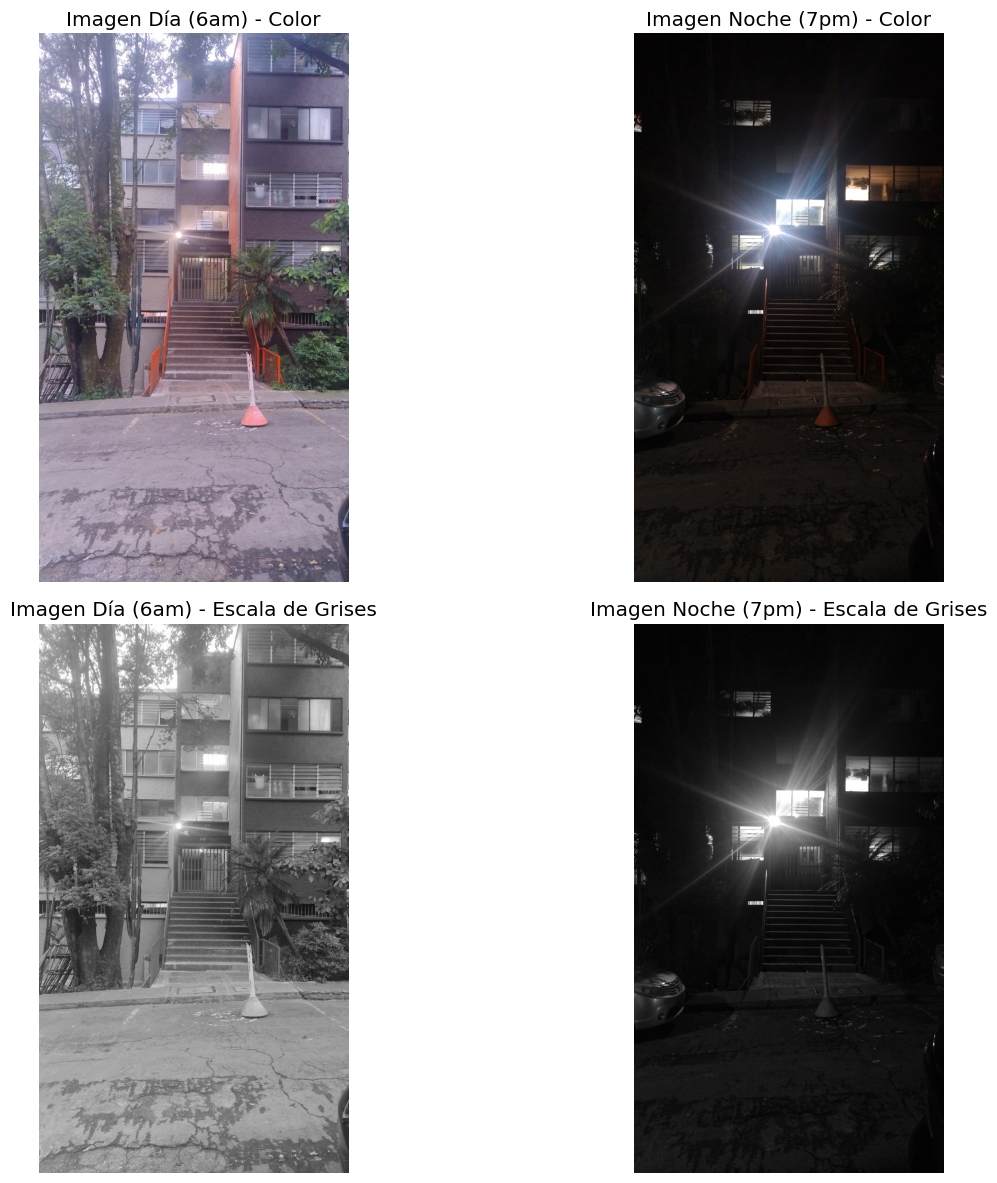

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Imágenes en color
axes[0, 0].imshow(img_day_rgb)
axes[0, 0].set_title('Imagen Día (6am) - Color')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_night_rgb)
axes[0, 1].set_title('Imagen Noche (7pm) - Color')
axes[0, 1].axis('off')

# Imágenes en escala de grises
axes[1, 0].imshow(img_day_gray, cmap='gray')
axes[1, 0].set_title('Imagen Día (6am) - Escala de Grises')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_night_gray, cmap='gray')
axes[1, 1].set_title('Imagen Noche (7pm) - Escala de Grises')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 3. Histogramas

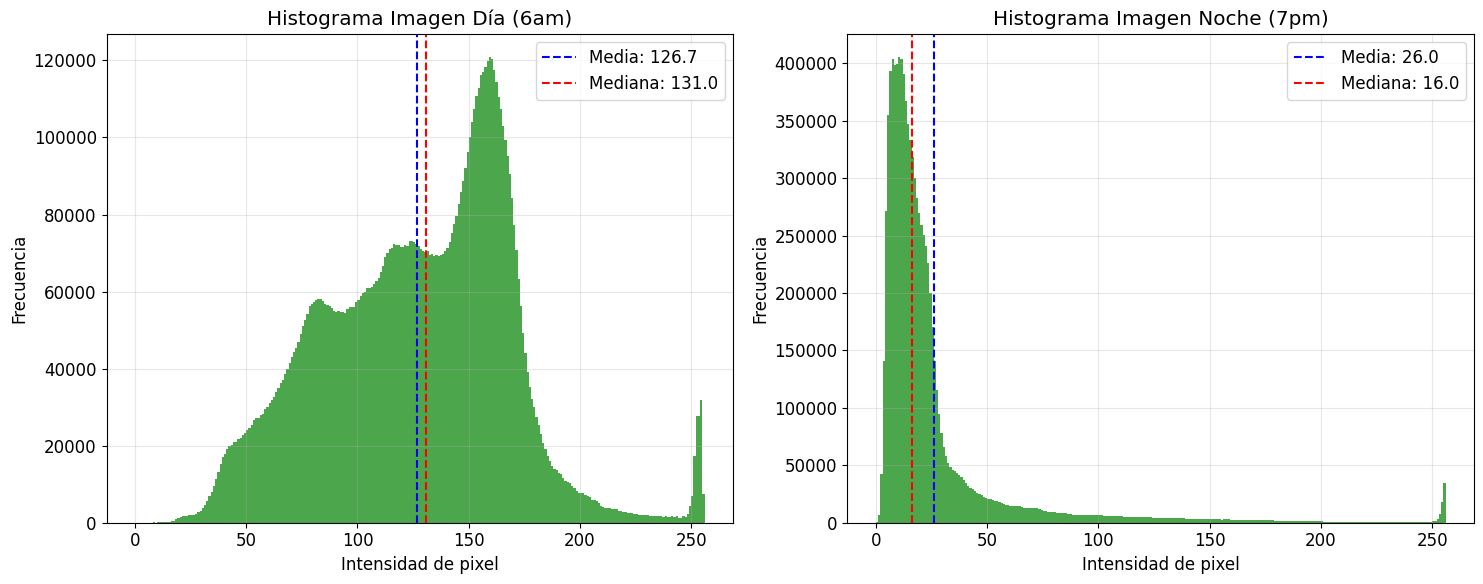


=== ESTADÍSTICAS DE LAS IMÁGENES ORIGINALES ===
Imagen Día:
  - Media: 126.70
  - Desviación estándar: 42.22
  - Mediana: 131.00
  - Rango: [1, 255]

Imagen Noche:
  - Media: 26.04
  - Desviación estándar: 35.86
  - Mediana: 16.00
  - Rango: [0, 255]


In [5]:
def calculate_histogram(image):
    """Calcular histograma de una imagen en escala de grises"""
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    return hist.flatten()

def plot_histogram(image, title, ax):
    """Plotear histograma con estadísticas"""
    hist = calculate_histogram(image)

    ax.hist(image.ravel(), bins=256, range=[0, 256], alpha=0.7, color='green')
    ax.set_xlabel('Intensidad de pixel')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Añadir estadísticas
    mean_val = np.mean(image)
    std_val = np.std(image)
    median_val = np.median(image)

    ax.axvline(mean_val, color='blue', linestyle='--', label=f'Media: {mean_val:.1f}')
    ax.axvline(median_val, color='red', linestyle='--', label=f'Mediana: {median_val:.1f}')
    ax.legend()

    return hist, mean_val, std_val, median_val

# Plotear histogramas originales
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

hist_day, mean_day, std_day, median_day = plot_histogram(
    img_day_gray, 'Histograma Imagen Día (6am)', axes[0]
)

hist_night, mean_night, std_night, median_night = plot_histogram(
    img_night_gray, 'Histograma Imagen Noche (7pm)', axes[1]
)

plt.tight_layout()
plt.show()

print("\n=== ESTADÍSTICAS DE LAS IMÁGENES ORIGINALES ===")
print(f"Imagen Día:")
print(f"  - Media: {mean_day:.2f}")
print(f"  - Desviación estándar: {std_day:.2f}")
print(f"  - Mediana: {median_day:.2f}")
print(f"  - Rango: [{img_day_gray.min()}, {img_day_gray.max()}]")

print(f"\nImagen Noche:")
print(f"  - Media: {mean_night:.2f}")
print(f"  - Desviación estándar: {std_night:.2f}")
print(f"  - Mediana: {median_night:.2f}")
print(f"  - Rango: [{img_night_gray.min()}, {img_night_gray.max()}]")

## 4. Ecualización del Histograma - Manual

In [6]:
def histogram_equalization(image):
    """
    Implementación manual de la ecualización de histograma usando CDF
    """
    # Calcular histograma
    hist = calculate_histogram(image)

    # Calcular CDF (Función de Distribución Acumulada)
    cdf = hist.cumsum()

    # Normalizar CDF
    cdf_normalized = cdf * 255 / cdf[-1]

    # Aplicar la transformación
    equalized = cdf_normalized[image]

    return equalized.astype(np.uint8), hist, cdf, cdf_normalized

# Aplicar ecualización manual
img_day_eq, hist_day_orig, cdf_day, cdf_day_norm = histogram_equalization(img_day_gray)
img_night_eq, hist_night_orig, cdf_night, cdf_night_norm = histogram_equalization(img_night_gray)

print("Ecualización finalizada")
print(f"Imagen día ecualizada - Rango: [{img_day_eq.min()}, {img_day_eq.max()}]")
print(f"Imagen noche ecualizada - Rango: [{img_night_eq.min()}, {img_night_eq.max()}]")

Ecualización finalizada
Imagen día ecualizada - Rango: [0, 255]
Imagen noche ecualizada - Rango: [0, 255]


## 5. Visualización funciones de transformación

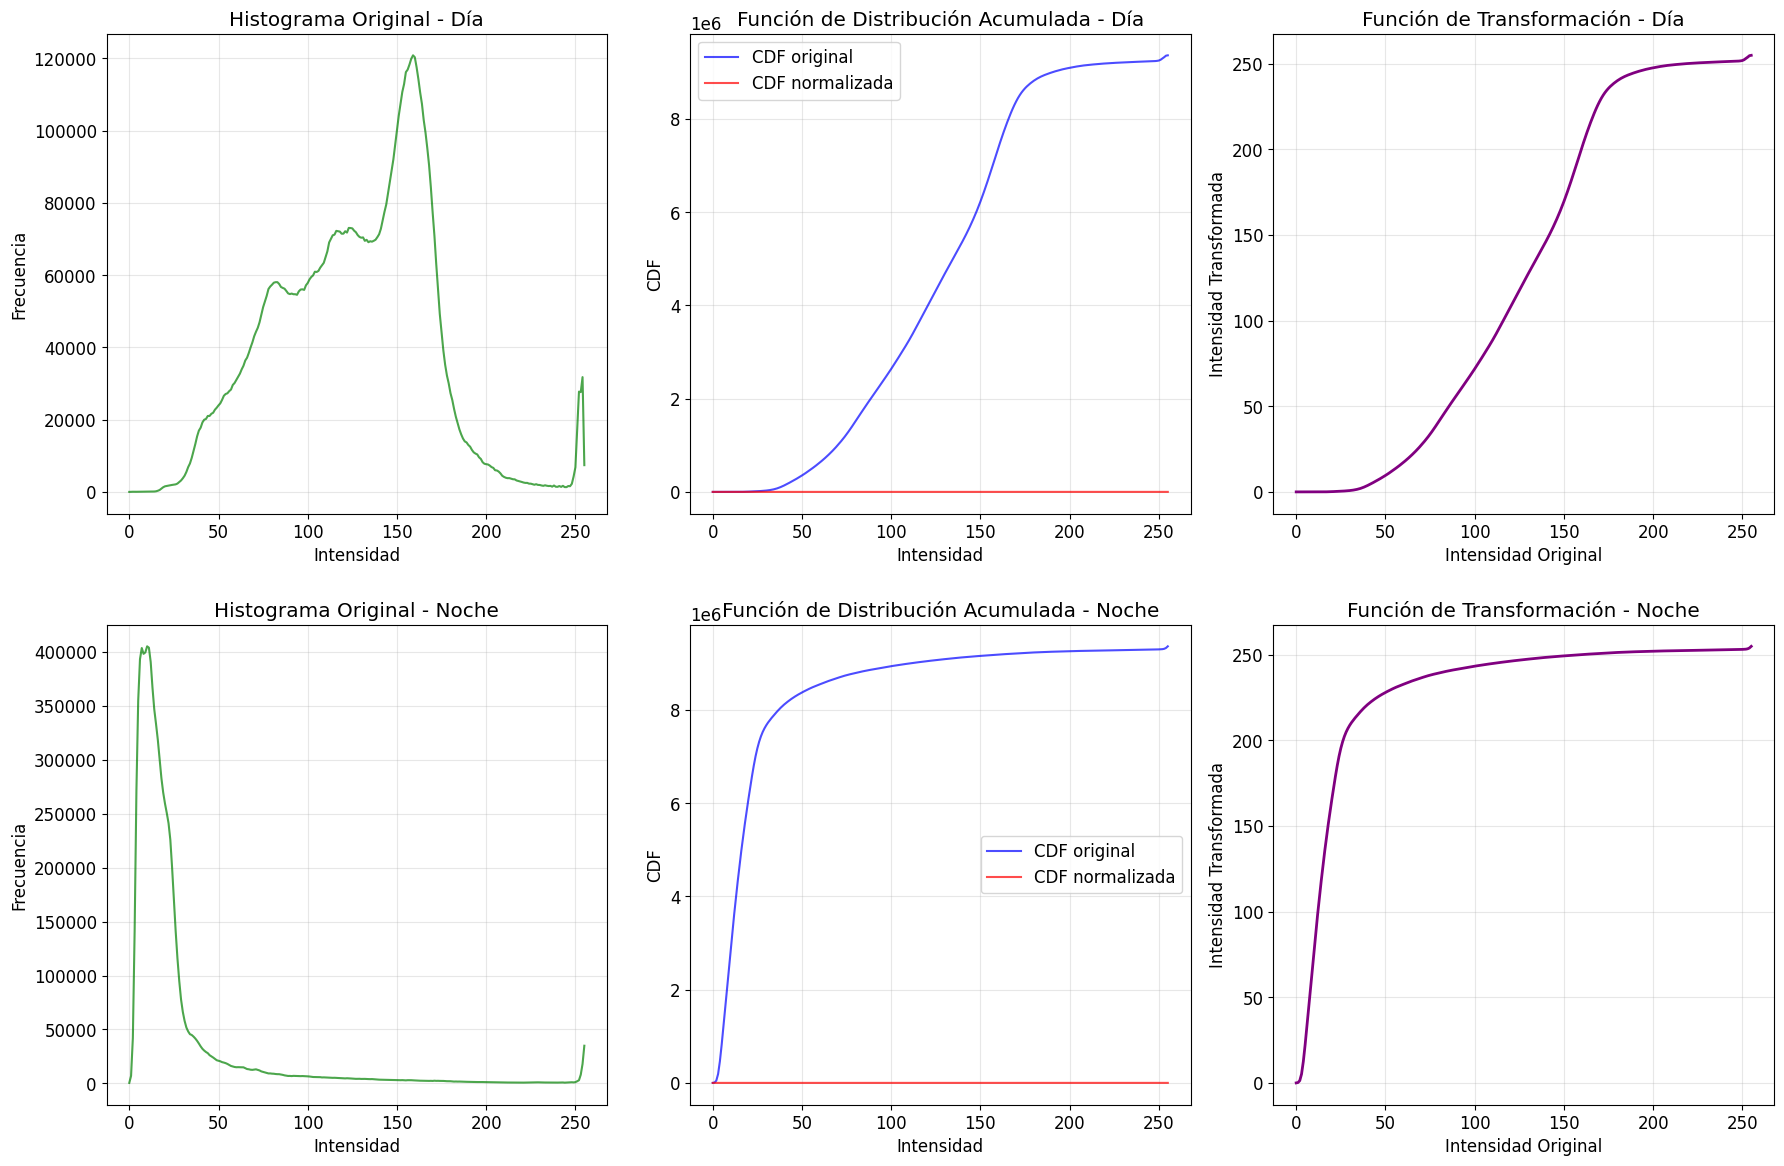

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Imagen día
axes[0, 0].plot(hist_day_orig, color='green', alpha=0.7)
axes[0, 0].set_title('Histograma Original - Día')
axes[0, 0].set_xlabel('Intensidad')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(cdf_day, color='blue', alpha=0.7, label='CDF original')
axes[0, 1].plot(cdf_day_norm, color='red', alpha=0.7, label='CDF normalizada')
axes[0, 1].set_title('Función de Distribución Acumulada - Día')
axes[0, 1].set_xlabel('Intensidad')
axes[0, 1].set_ylabel('CDF')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(range(256), cdf_day_norm, color='purple', linewidth=2)
axes[0, 2].set_title('Función de Transformación - Día')
axes[0, 2].set_xlabel('Intensidad Original')
axes[0, 2].set_ylabel('Intensidad Transformada')
axes[0, 2].grid(True, alpha=0.3)

# Imagen noche
axes[1, 0].plot(hist_night_orig, color='green', alpha=0.7)
axes[1, 0].set_title('Histograma Original - Noche')
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(cdf_night, color='blue', alpha=0.7, label='CDF original')
axes[1, 1].plot(cdf_night_norm, color='red', alpha=0.7, label='CDF normalizada')
axes[1, 1].set_title('Función de Distribución Acumulada - Noche')
axes[1, 1].set_xlabel('Intensidad')
axes[1, 1].set_ylabel('CDF')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(range(256), cdf_night_norm, color='purple', linewidth=2)
axes[1, 2].set_title('Función de Transformación - Noche')
axes[1, 2].set_xlabel('Intensidad Original')
axes[1, 2].set_ylabel('Intensidad Transformada')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparación de Imágenes: Originales vs Equalizadas

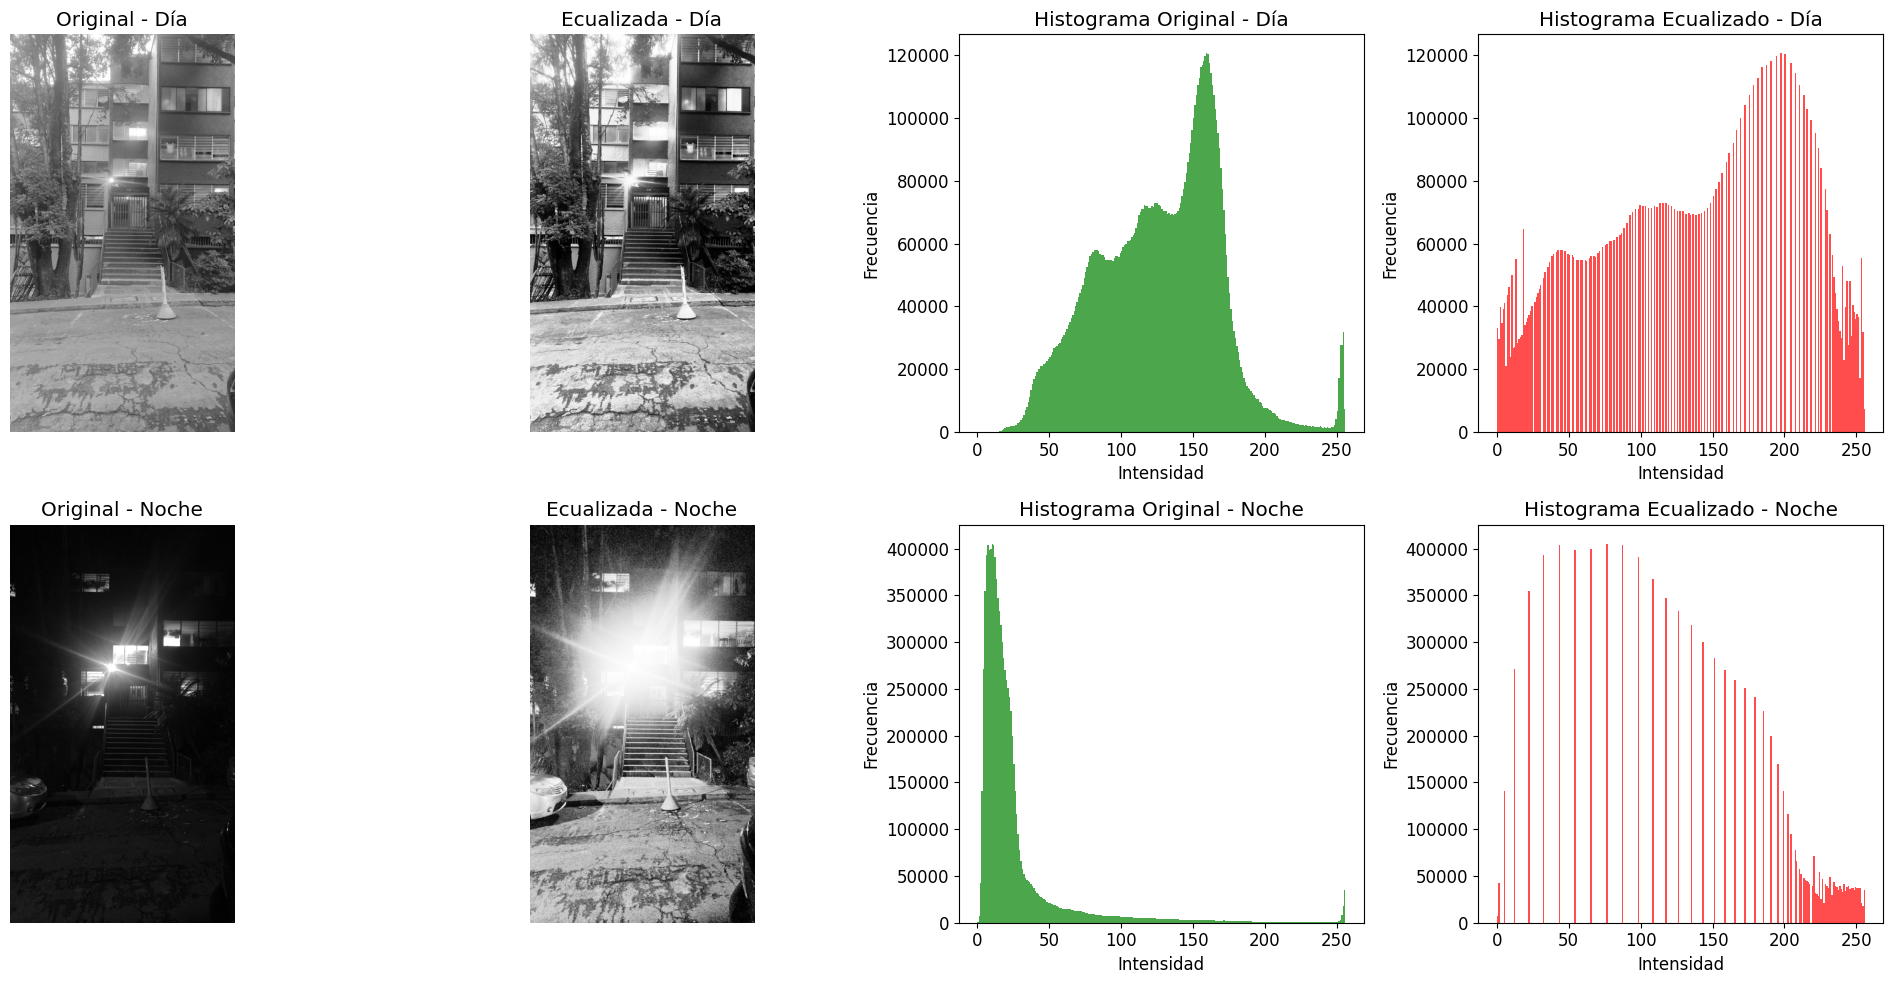

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Fila 1: Imagen día
axes[0, 0].imshow(img_day_gray, cmap='gray')
axes[0, 0].set_title('Original - Día')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_day_eq, cmap='gray')
axes[0, 1].set_title('Ecualizada - Día')
axes[0, 1].axis('off')

# Histogramas día
axes[0, 2].hist(img_day_gray.ravel(), bins=256, range=[0, 256], alpha=0.7, color='green')
axes[0, 2].set_title('Histograma Original - Día')
axes[0, 2].set_xlabel('Intensidad')
axes[0, 2].set_ylabel('Frecuencia')

axes[0, 3].hist(img_day_eq.ravel(), bins=256, range=[0, 256], alpha=0.7, color='red')
axes[0, 3].set_title('Histograma Ecualizado - Día')
axes[0, 3].set_xlabel('Intensidad')
axes[0, 3].set_ylabel('Frecuencia')

# Fila 2: Imagen noche
axes[1, 0].imshow(img_night_gray, cmap='gray')
axes[1, 0].set_title('Original - Noche')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_night_eq, cmap='gray')
axes[1, 1].set_title('Ecualizada - Noche')
axes[1, 1].axis('off')

# Histogramas noche
axes[1, 2].hist(img_night_gray.ravel(), bins=256, range=[0, 256], alpha=0.7, color='green')
axes[1, 2].set_title('Histograma Original - Noche')
axes[1, 2].set_xlabel('Intensidad')
axes[1, 2].set_ylabel('Frecuencia')

axes[1, 3].hist(img_night_eq.ravel(), bins=256, range=[0, 256], alpha=0.7, color='red')
axes[1, 3].set_title('Histograma Ecualizado - Noche')
axes[1, 3].set_ylabel('Frecuencia')
axes[1, 3].set_xlabel('Intensidad')

plt.tight_layout()
plt.show()

## 7. Análisis de cuantitativo de las mejoras

In [9]:
def calculate_image_metrics(image, title):
    """Calcular métricas de calidad de imagen"""
    mean_val = np.mean(image)
    std_val = np.std(image)
    min_val = np.min(image)
    max_val = np.max(image)

    # Entropía (medida de información)
    hist = calculate_histogram(image)
    hist_norm = hist / hist.sum()
    hist_norm = hist_norm[hist_norm > 0]  # Evitar log(0)
    entropy = -np.sum(hist_norm * np.log2(hist_norm))

    # Contraste (desviación estándar normalizada)
    contrast = std_val / mean_val if mean_val > 0 else 0

    print(f"\n=== {title} ===")
    print(f"Media: {mean_val:.2f}")
    print(f"Desviación estándar: {std_val:.2f}")
    print(f"Rango: [{min_val}, {max_val}]")
    print(f"Entropía: {entropy:.2f} bits")
    print(f"Contraste relativo: {contrast:.3f}")

    return {
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val,
        'entropy': entropy,
        'contrast': contrast
    }

# Calcular métricas para todas las imágenes
metrics_day_orig = calculate_image_metrics(img_day_gray, "IMAGEN DÍA ORIGINAL")
metrics_day_eq = calculate_image_metrics(img_day_eq, "IMAGEN DÍA ECUALIZADA")
metrics_night_orig = calculate_image_metrics(img_night_gray, "IMAGEN NOCHE ORIGINAL")
metrics_night_eq = calculate_image_metrics(img_night_eq, "IMAGEN NOCHE ECUALIZADA")


=== IMAGEN DÍA ORIGINAL ===
Media: 126.70
Desviación estándar: 42.22
Rango: [1, 255]
Entropía: 7.31 bits
Contraste relativo: 0.333

=== IMAGEN DÍA ECUALIZADA ===
Media: 127.91
Desviación estándar: 73.78
Rango: [0, 255]
Entropía: 7.13 bits
Contraste relativo: 0.577

=== IMAGEN NOCHE ORIGINAL ===
Media: 26.04
Desviación estándar: 35.86
Rango: [0, 255]
Entropía: 5.78 bits
Contraste relativo: 1.377

=== IMAGEN NOCHE ECUALIZADA ===
Media: 130.47
Desviación estándar: 72.08
Rango: [0, 255]
Entropía: 5.52 bits
Contraste relativo: 0.552


## 8. Comparación equalizaciones (Función de OpenCV/Manual)

In [10]:
# Ecualización usando OpenCV para comparación
img_day_eq_cv = cv2.equalizeHist(img_day_gray)
img_night_eq_cv = cv2.equalizeHist(img_night_gray)

# Verificar que los resultados son iguales
day_diff = np.abs(img_day_eq.astype(float) - img_day_eq_cv.astype(float))
night_diff = np.abs(img_night_eq.astype(float) - img_night_eq_cv.astype(float))

print(f"Diferencia máxima día (manual vs OpenCV): {day_diff.max()}")
print(f"Diferencia máxima noche (manual vs OpenCV): {night_diff.max()}")
print(f"Diferencia promedio día: {day_diff.mean():.6f}")
print(f"Diferencia promedio noche: {night_diff.mean():.6f}")

if day_diff.max() < 1 and night_diff.max() < 1:
    print("\n Done: La implementación manual es correcta (diferencias < 1 pixel)")
else:
    print("\n Warning: Hay diferencias significativas con la implementación de OpenCV")

Diferencia máxima día (manual vs OpenCV): 1.0
Diferencia máxima noche (manual vs OpenCV): 1.0
Diferencia promedio día: 0.553010
Diferencia promedio noche: 0.636768



## 9. Análisis de las transformaciones

In [11]:
def analyze_transformation(cdf_norm, title):
    """Analizar la función de transformación"""
    print(f"\n=== ANÁLISIS DE TRANSFORMACIÓN - {title} ===")

    # Encontrar rangos de intensidad más transformados
    derivative = np.diff(cdf_norm)
    high_stretch = np.where(derivative > np.percentile(derivative, 90))[0]
    low_stretch = np.where(derivative < np.percentile(derivative, 10))[0]

    print(f"Intensidades más estiradas (mayor ganancia): {high_stretch[:5]} - {high_stretch[-5:]}")
    print(f"Intensidades menos estiradas (menor ganancia): {low_stretch[:5]} - {low_stretch[-5:]}")

    # Puntos de inflexión importantes
    quarter_point = np.where(cdf_norm >= 64)[0][0] if len(np.where(cdf_norm >= 64)[0]) > 0 else 0
    half_point = np.where(cdf_norm >= 128)[0][0] if len(np.where(cdf_norm >= 128)[0]) > 0 else 0
    three_quarter_point = np.where(cdf_norm >= 192)[0][0] if len(np.where(cdf_norm >= 192)[0]) > 0 else 0

    print(f"Primer cuartil (64) alcanzado en intensidad: {quarter_point}")
    print(f"Punto medio (128) alcanzado en intensidad: {half_point}")
    print(f"Tercer cuartil (192) alcanzado en intensidad: {three_quarter_point}")

    return derivative, high_stretch, low_stretch

# Analizar transformaciones
deriv_day, high_day, low_day = analyze_transformation(cdf_day_norm, "IMAGEN DÍA")
deriv_night, high_night, low_night = analyze_transformation(cdf_night_norm, "IMAGEN NOCHE")


=== ANÁLISIS DE TRANSFORMACIÓN - IMAGEN DÍA ===
Intensidades más estiradas (mayor ganancia): [143 144 145 146 147] - [164 165 166 167 168]
Intensidades menos estiradas (menor ganancia): [0 1 2 3 4] - [238 239 241 243 244]
Primer cuartil (64) alcanzado en intensidad: 95
Punto medio (128) alcanzado en intensidad: 131
Tercer cuartil (192) alcanzado en intensidad: 158

=== ANÁLISIS DE TRANSFORMACIÓN - IMAGEN NOCHE ===
Intensidades más estiradas (mayor ganancia): [2 3 4 5 6] - [23 24 25 26 27]
Intensidades menos estiradas (menor ganancia): [211 212 213 214 215] - [239 240 241 243 244]
Primer cuartil (64) alcanzado en intensidad: 9
Punto medio (128) alcanzado en intensidad: 16
Tercer cuartil (192) alcanzado en intensidad: 25


## 10. Visualización Final (Comparación)

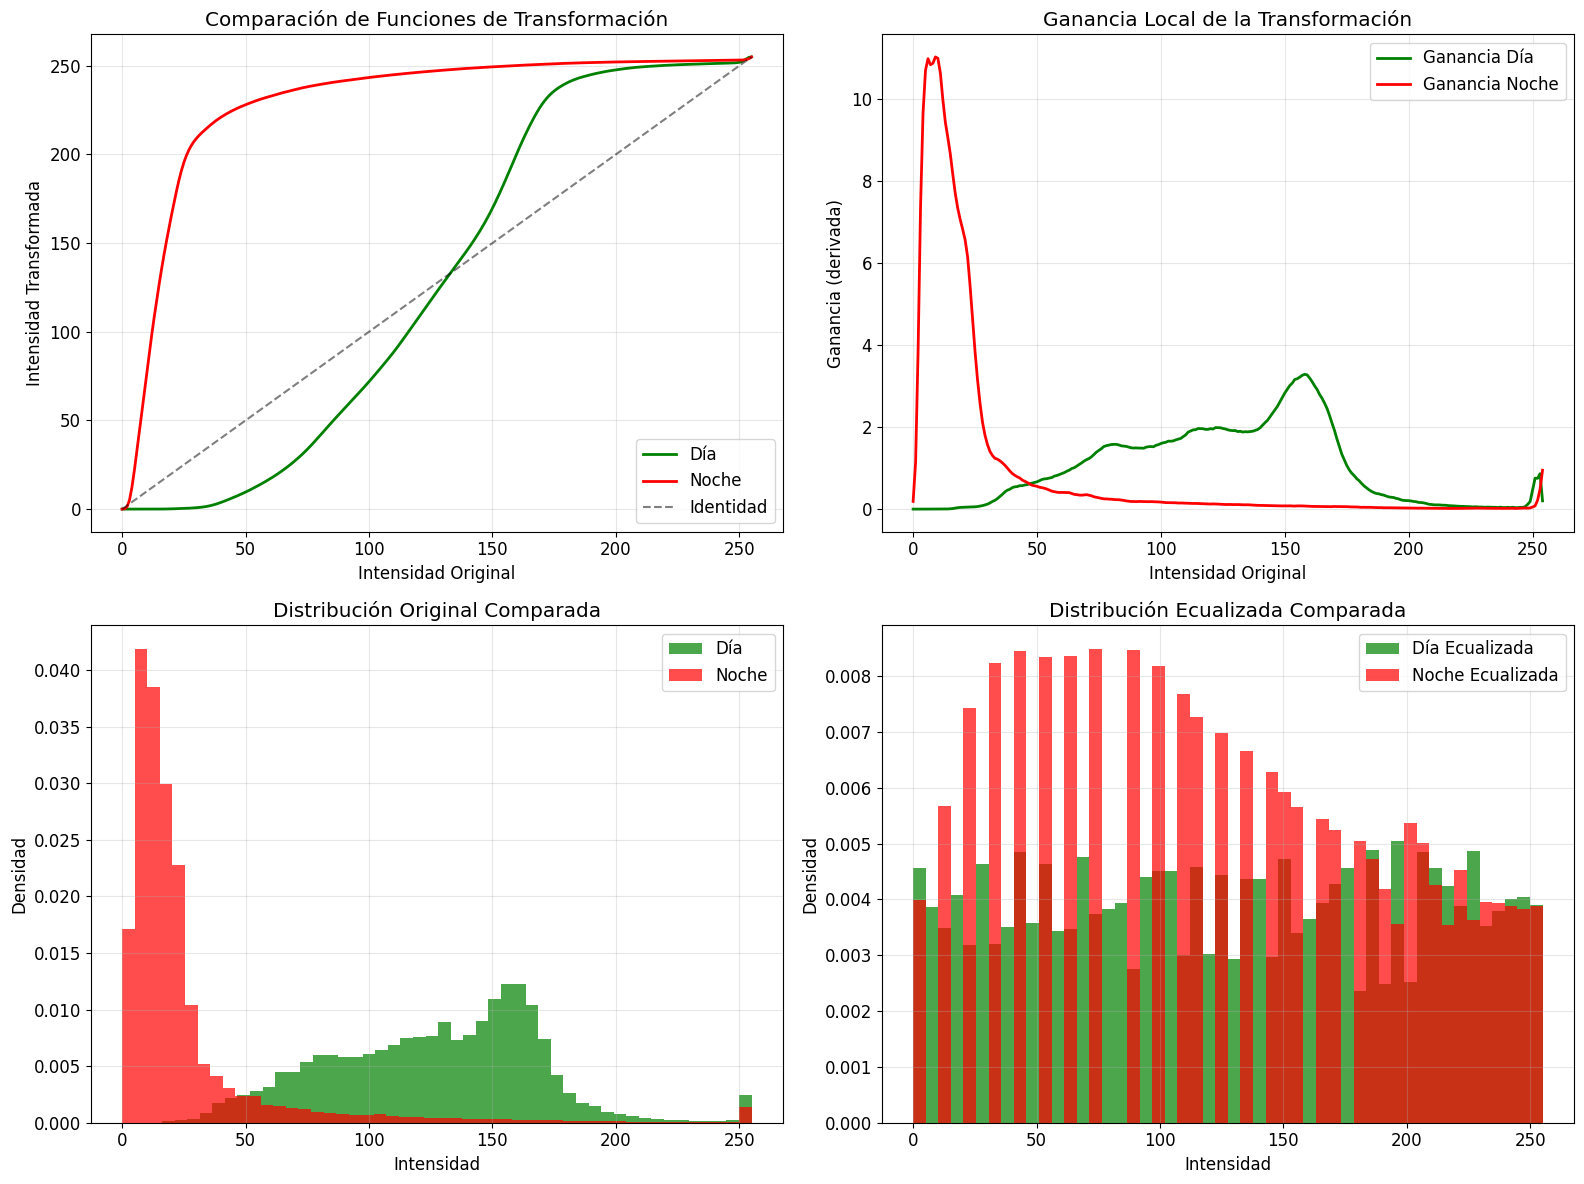

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Comparación directa de las funciones de transformación
axes[0, 0].plot(range(256), cdf_day_norm, 'g-', linewidth=2, label='Día')
axes[0, 0].plot(range(256), cdf_night_norm, 'r-', linewidth=2, label='Noche')
axes[0, 0].plot(range(256), range(256), 'k--', alpha=0.5, label='Identidad')
axes[0, 0].set_title('Comparación de Funciones de Transformación')
axes[0, 0].set_xlabel('Intensidad Original')
axes[0, 0].set_ylabel('Intensidad Transformada')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Derivadas (ganancia local)
axes[0, 1].plot(range(255), deriv_day, 'g-', linewidth=2, label='Ganancia Día')
axes[0, 1].plot(range(255), deriv_night, 'r-', linewidth=2, label='Ganancia Noche')
axes[0, 1].set_title('Ganancia Local de la Transformación')
axes[0, 1].set_xlabel('Intensidad Original')
axes[0, 1].set_ylabel('Ganancia (derivada)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Histogramas originales superpuestos
axes[1, 0].hist(img_day_gray.ravel(), bins=50, alpha=0.7, color='green',
                label='Día', density=True)
axes[1, 0].hist(img_night_gray.ravel(), bins=50, alpha=0.7, color='red',
                label='Noche', density=True)
axes[1, 0].set_title('Distribución Original Comparada')
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Histogramas ecualizados superpuestos
axes[1, 1].hist(img_day_eq.ravel(), bins=50, alpha=0.7, color='green',
                label='Día Ecualizada', density=True)
axes[1, 1].hist(img_night_eq.ravel(), bins=50, alpha=0.7, color='red',
                label='Noche Ecualizada', density=True)
axes[1, 1].set_title('Distribución Ecualizada Comparada')
axes[1, 1].set_xlabel('Intensidad')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Conclusiones




In [13]:
print("="*70)
print("CONCLUSIONES DEL ANÁLISIS DE ECUALIZACIÓN DE HISTOGRAMA")
print("="*70)

print("\n1. DIFERENCIAS ENTRE HISTOGRAMAS ORIGINALES:")
print("-" * 50)

print(f"\nImagen DÍA (6am):")
print(f"• Media: {metrics_day_orig['mean']:.1f} - Imagen más brillante")
print(f"• Desviación estándar: {metrics_day_orig['std']:.1f}")
print(f"• Rango utilizado: [{metrics_day_orig['min']}, {metrics_day_orig['max']}]")
print(f"• Entropía: {metrics_day_orig['entropy']:.2f} bits")

print(f"\nImagen NOCHE (7pm):")
print(f"• Media: {metrics_night_orig['mean']:.1f} - Imagen más oscura")
print(f"• Desviación estándar: {metrics_night_orig['std']:.1f}")
print(f"• Rango utilizado: [{metrics_night_orig['min']}, {metrics_night_orig['max']}]")
print(f"• Entropía: {metrics_night_orig['entropy']:.2f} bits")

print("\n2. CARACTERÍSTICAS DE LAS TRANSFORMACIONES:")
print("-" * 50)

# Analizar las CDFs
day_steep_regions = len(np.where(deriv_day > np.mean(deriv_day) + np.std(deriv_day))[0])
night_steep_regions = len(np.where(deriv_night > np.mean(deriv_night) + np.std(deriv_night))[0])

print(f"\nTransformación DÍA:")
print(f"• Regiones con alta ganancia: {day_steep_regions} intensidades")
print(f"• Mejora de contraste: {(metrics_day_eq['contrast']/metrics_day_orig['contrast']-1)*100:.1f}%")
print(f"• Mejora de entropía: {(metrics_day_eq['entropy']/metrics_day_orig['entropy']-1)*100:.1f}%")

print(f"\nTransformación NOCHE:")
print(f"• Regiones con alta ganancia: {night_steep_regions} intensidades")
print(f"• Mejora de contraste: {(metrics_night_eq['contrast']/metrics_night_orig['contrast']-1)*100:.1f}%")
print(f"• Mejora de entropía: {(metrics_night_eq['entropy']/metrics_night_orig['entropy']-1)*100:.1f}%")

print("\n3. EFECTOS DE LA ECUALIZACIÓN:")
print("-" * 50)
print("• En las imágenes ecualizadas se observa una distribución más uniforme")
print("• La imagen de noche muestra mayor mejora visual relaciona con una mejor distribución de los tonos")
print("• Se preservan los detalles mientras se mejora el contraste global")
print("• Las transformaciones son no-lineales y específicas para cada imagen")

print("\n" + "="*70)

CONCLUSIONES DEL ANÁLISIS DE ECUALIZACIÓN DE HISTOGRAMA

1. DIFERENCIAS ENTRE HISTOGRAMAS ORIGINALES:
--------------------------------------------------

Imagen DÍA (6am):
• Media: 126.7 - Imagen más brillante
• Desviación estándar: 42.2
• Rango utilizado: [1, 255]
• Entropía: 7.31 bits

Imagen NOCHE (7pm):
• Media: 26.0 - Imagen más oscura
• Desviación estándar: 35.9
• Rango utilizado: [0, 255]
• Entropía: 5.78 bits

2. CARACTERÍSTICAS DE LAS TRANSFORMACIONES:
--------------------------------------------------

Transformación DÍA:
• Regiones con alta ganancia: 46 intensidades
• Mejora de contraste: 73.1%
• Mejora de entropía: -2.4%

Transformación NOCHE:
• Regiones con alta ganancia: 24 intensidades
• Mejora de contraste: -59.9%
• Mejora de entropía: -4.5%

3. EFECTOS DE LA ECUALIZACIÓN:
--------------------------------------------------
• En las imágenes ecualizadas se observa una distribución más uniforme
• La imagen de noche muestra mayor mejora visual relaciona con una mejor distr

## **Conclusiones Finales**

---

## **Histogramas**


* **Imagen Diurna (6 a.m.):** Es una imagen una distribución de frecuencias amplia, con predominancia en los tonos medios y altos. Su media de brillo ($126.7$) es alta, y su **entropía** ($7.31$ bits) también, lo que significa que tiene una **amplia variedad de tonos** (desde muy claros hasta oscuros) y muchos detalles visibles.

* **Imagen Nocturna (7 p.m.):** Es una imagen **oscura y limitada**. Su media de brillo es muy baja ($26.0$), y su **entropía** ($5.78$ bits) es menor, lo que confirma que predominan los **tonos negros y sombras**; le falta luz.



**Conclusión:** El histograma diurno indica diversidad y equilibrio en los tonos (característico de imágenes con luz natural abundante), mientras que el histograma nocturno refleja predominancia de sombras profundas y mínima presencia de luz, características propias de imágenes tomadas en condiciones de baja iluminación.


### **Ecualización**

* **En la Imagen Diurna:** La ecualización fue útil para **aumentar notoriamente el contraste** (un $73.1\%$ más). Sin embargo, redujo ligeramente la entropía ($-2.4\%$), esto implica que **no añadió nueva información visual**, sino que solo estiró los tonos que ya existían.
* **En la Imagen Nocturna:** El resultado fue paradójico: el contraste se redujo ($-59.9\%$), al igual que la entropía ($-4.5\%$). Esto probablemente indica que la ecualización forzó tanto la expansión de los tonos oscuros que terminó **saturando o perdiendo algunos matices finos** en las sombras.

**Conclusión:** La ecualización no funciona igual para todas las fotos. Es **más efectiva y segura** cuando la foto de partida ya tiene un rango de tonos decente (como la imagen diurna), aunque su impacto visual se note menos.

A nivel estructural, la ecualización logró que el histograma de ambas imágenes fuera más uniforme. Esto implicó:

* **Imagen Nocturna:** presentó una **evidente mejoría visual**. Al expandir esos tonos oscuros, se hicieron visibles detalles que estaban completamente ocultos en la oscuridad.
* **Imagen Diurna:** experimentó cambios muy sutiles. Como la foto ya estaba bien expuesta, la ecualización no aportó una "mejora" real a la información, y en algunos casos, pudo hacerla lucir un poco menos natural.

---

## **Comentarios finales**

1.  **La ecualización es una excelente herramienta para "rescatar" imágenes oscuras** o subexpuestas, ya que revela detalles ocultos.
2.  **En imágenes con buenas condiciones de iluminacion** Aplicar ecualización  puede **reducir su naturalidad** o alterar su contraste local.
3.  **El efecto es global:** La ecualización usa la información de toda la imagen para hacer un único ajuste, lo que puede causar problemas como **saturación** si la iluminación original no era uniforme.
